In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

digits = load_digits()
digits.data[0].shape

(64,)

In [2]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

C:\python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


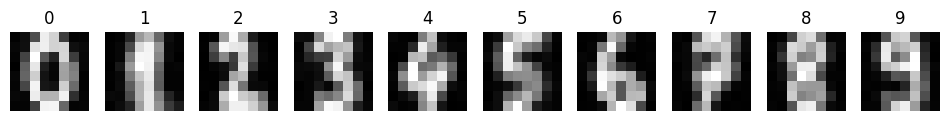

In [3]:
latent_dim = 8

plt.figure(figsize=(12, 3))

for digit in range(10):

    X = digits.data[digits.target == digit] / 16.0 # 0.0~1.0
    X = X.astype(np.float32)

    mean_img = X.mean(axis=0)

    # Generator 64픽셀을 만드는 모형
    generator = Sequential([
        Dense(32, activation='relu', input_dim=latent_dim),
        Dense(64, activation='sigmoid')
    ])

    generator.compile(
        optimizer=Adam(0.001),
        loss='mse'
    )
    # 학습
    for step in range(1000):  #0.0~1.0사이의 랜덤값 (32행,8열)
        noise = np.random.normal(0, 1, (32, latent_dim))
        target = mean_img + np.random.normal(0, 0.05, mean_img.shape) #노이즈 추가
        target = np.clip(target, 0, 1) # 0보다 작으면 0, 1보다 크면 1로 설정
        generator.train_on_batch(noise, np.tile(target, (32, 1)))

    # 생성 결과
    noise = np.random.normal(0, 1, (1, latent_dim))
    sample = generator.predict(noise, verbose=0)[0]

    plt.subplot(1, 10, digit + 1)
    plt.imshow(sample.reshape(8, 8), cmap='gray')
    plt.title(str(digit))
    plt.axis('off')

plt.show()